🎯 **You Sank My Function** — Black-Box Optimisation Capstone · Imperial College Business School

**Weekly pipeline** · [04 Consolidate](../pipeline/04_consolidate_data.ipynb) → [05 Suggest Engine](../pipeline/05_suggest_engine.ipynb) → [06 Diagnose](../pipeline/06_diagnose.ipynb)
**Tutorials** · [01 GP theory](../tutorials/01_gp_bayesian_optimization_tutorial.ipynb) · [02 Acquisition engine](../tutorials/02_gp_suggest_input_tutorial.ipynb) · [03 EDA & prototype](../tutorials/03_capstone_eda_and_prototype.ipynb)
**Diagnostics** · [A1 SVM](../diagnostics/A1_svm_analysis.ipynb) · [A2 Logistic regression](../diagnostics/A2_logistic_regression.ipynb) · [A3 Landscape gallery](../diagnostics/A3_landscape_gallery.ipynb)

> 📍 **This notebook** — **Phase 1 of the weekly pipeline.** Rebuilds the single tidy observation table (Week 0 + all weekly rounds) from raw sources, audits integrity, and exports `consolidated_observations.csv` — the only file Phase 2 reads.

---

# 04 · Data Consolidation — *You Sank My Function*
### Phase 1 of the transparent query-selection pipeline

**Purpose.** Rebuild a single, tidy record of every observation we have — the
initial design (Week 0) plus every weekly query — from the *raw* sources, so
that nothing downstream depends on hand-maintained notes. The Phase 2 engine
(`05_suggest_engine`) reads **only** the table produced here.

**Why this exists.** The weekly decisions were originally made conversationally.
This notebook re-derives the *state* those decisions acted on, deterministically
and inspectably, so the whole process becomes reproducible rather than anecdotal.

---

### The data model

One long-format table, one row per observation:

| column | meaning |
|---|---|
| `function` | 1–8 |
| `dim` | input dimensionality |
| `week` | 0 = initial design, 1..N = weekly query rounds |
| `source` | `initial` or `weekly` |
| `x1 … xd` | the input vector (NaN for unused higher dims) |
| `y` | the returned objective value (maximisation) |

### The two input sources

1. **Week 0 — initial designs.** Either per-function `function_N/initial_inputs.npy`
   + `initial_outputs.npy`, *or* the tidy `fN_data.csv` files. Both encode the
   same points; the loader accepts whichever you have.
2. **Weeks 1…N — cumulative weekly files.** `weekly_inputs.txt` / `weekly_outputs.txt`.
   **Each row is one week; each row holds 8 entries (functions 1→8).** The files
   are *cumulative*: after week 3 they contain three rows. Appending next week's
   row is the only manual step, and this notebook then re-consolidates everything.


## 0 · Configuration — set your paths here

In [1]:
import os, re, ast, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

# ── PATH CONFIGURATION (portable) ───────────────────────────────────────
# The kernel's working directory is NOT reliably the notebook's folder:
# JupyterLab, VS Code and nbconvert each set it differently. So nothing
# below assumes it. Resolution order:
#   1. BBO_DATA_DIR, if set
#   2. otherwise walk upward from the working directory looking for a
#      folder that actually contains the challenge data
#   3. otherwise stop with instructions
#
# DATA_DIR holds EITHER the fN_data.csv files OR the function_N/
# subfolders (initial_inputs.npy / initial_outputs.npy) — both layouts
# are supported — plus the cumulative inputs.txt / outputs.txt.

def _is_data_dir(p):
    """True if p looks like the challenge data folder."""
    if not os.path.isdir(p):
        return False
    return (os.path.isfile(os.path.join(p, "inputs.txt"))
            or any(os.path.isfile(os.path.join(p, f"f{i}_data.csv")) for i in range(1, 9))
            or any(os.path.isdir(os.path.join(p, f"function_{i}")) for i in range(1, 9)))

def _find_data_dir():
    env = os.environ.get("BBO_DATA_DIR")
    if env:
        return os.path.abspath(env), "BBO_DATA_DIR"
    here = os.path.abspath("")
    for _ in range(6):                      # walk up a few levels
        for cand in ("data", "initial_data", os.path.join("..", "data")):
            p = os.path.abspath(os.path.join(here, cand))
            if _is_data_dir(p):
                return p, "auto-detected"
        parent = os.path.dirname(here)
        if parent == here:
            break
        here = parent
    return None, None

DATA_DIR, _how = _find_data_dir()
if DATA_DIR is None:
    raise FileNotFoundError(
        "Could not locate the challenge data folder.\n\n"
        "Set BBO_DATA_DIR and re-run this cell — either in your shell before\n"
        "launching Jupyter, or in a cell above this one:\n\n"
        "    import os\n"
        "    os.environ['BBO_DATA_DIR'] = r'D:\\Capstone Challange\\initial_data'\n\n"
        "It should point at the folder holding inputs.txt / outputs.txt and the\n"
        "per-function initial designs.\n"
        f"(searched upward from {os.path.abspath('')})"
    )

WEEKLY_INPUTS  = os.path.join(DATA_DIR, "inputs.txt")    # cumulative; one row per week
WEEKLY_OUTPUTS = os.path.join(DATA_DIR, "outputs.txt")

# consolidated_observations.csv must land where 05 and 06 look for it.
# Prefer an explicit override, then the repo's pipeline/ folder beside
# data/, and only then the working directory.
_repo_root = os.path.dirname(DATA_DIR)
_pipeline  = os.path.join(_repo_root, "pipeline")
OUT_DIR = (os.environ.get("BBO_OUT_DIR")
           or (_pipeline if os.path.isdir(_pipeline) else os.path.abspath("")))
# ─────────────────────────────────────────────────────────────────────────

os.makedirs(OUT_DIR, exist_ok=True)
print(f"DATA_DIR      : {DATA_DIR}   [{_how}]")
print("WEEKLY_INPUTS :", WEEKLY_INPUTS, "" if os.path.isfile(WEEKLY_INPUTS) else "  <-- MISSING")
print("WEEKLY_OUTPUTS:", WEEKLY_OUTPUTS, "" if os.path.isfile(WEEKLY_OUTPUTS) else "  <-- MISSING")
print("OUT_DIR       :", os.path.abspath(OUT_DIR))


DATA_DIR      : C:\Users\USER\data   [auto-detected]
WEEKLY_INPUTS : C:\Users\USER\data\inputs.txt 
WEEKLY_OUTPUTS: C:\Users\USER\data\outputs.txt 
OUT_DIR       : C:\Users\USER


## 1 · Function metadata (reconciled — synced with the Phase-2 RECORDS, Week 4)

The single source of truth for each function's dimensionality, working
hypothesis and current status. Everything downstream keys off this table, so it
lives in one editable place. Status summarises the Phase-2 stance:

- **solved** → optimum banked, minimal-change / hold rule applies (F7, F8)
- **modelled** → a trusted parametric or surrogate model is climbing (F4, F5, F6)
- **signal_found** → sharp source located, refining via inversion (F1)
- **uncertain** → still exploring structure (F2)
- **near_ceiling** → headroom exhausted, deprioritised (F3)

> ⚠️ *Maintenance note:* this table was previously allowed to drift from the
> Phase-2 `RECORDS` (e.g. F3 was still labelled "solved" after its Hartmann
> identity had been double-refuted). It is now updated together with the
> RECORDS each week. Saved outputs below may show the pre-sync state until
> the notebook is re-run.

In [2]:
FUNCTION_META = {
    1: dict(dim=2, hypothesis="radiation field / hidden source (signal FOUND W3)", status="signal_found", log_y=False),
    2: dict(dim=2, hypothesis="single high-x1 ridge (noisy; x2 ambiguous)",        status="uncertain",    log_y=False),
    3: dict(dim=3, hypothesis="Hartmann-3D REFUTED; bounded plateau near 0",       status="near_ceiling", log_y=False),
    4: dict(dim=4, hypothesis="single broad basin, optimum below centre",          status="modelled",     log_y=False),
    5: dict(dim=4, hypothesis="unimodal, huge dynamic range (Rosenbrock-like)",    status="modelled",     log_y=True),
    6: dict(dim=5, hypothesis="separable 5-term recipe (ST rejected)",             status="modelled",     log_y=False),
    7: dict(dim=6, hypothesis="Hartmann-6D negated — CONFIRMED",                   status="solved",       log_y=False),
    8: dict(dim=8, hypothesis="separable weighted quadratic — solved",             status="solved",       log_y=False),
}
DIMS = {f: m["dim"] for f, m in FUNCTION_META.items()}
pd.DataFrame(FUNCTION_META).T

,dim,hypothesis,status,log_y
1,2,radiation field / hidden source (signal FOUND W3),signal_found,False
2,2,single high-x1 ridge (noisy; x2 ambiguous),uncertain,False
3,3,Hartmann-3D REFUTED; bounded plateau near 0,near_ceiling,False
4,4,"single broad basin, optimum below centre",modelled,False
5,4,"unimodal, huge dynamic range (Rosenbrock-like)",modelled,True
6,5,separable 5-term recipe (ST rejected),modelled,False
7,6,Hartmann-6D negated — CONFIRMED,solved,False
8,8,separable weighted quadratic — solved,solved,False


## 2 · Load Week 0 — the initial designs

Tries the per-function `.npy` layout first, then falls back to the tidy
`fN_data.csv` files. Either way we end up with `{function: (X, y)}`.

In [3]:
def load_initial(function_id, data_dir=DATA_DIR):
    """Return (X, y) for one function's initial design, from .npy or CSV."""
    d = DIMS[function_id]

    # (a) per-function .npy folder: function_N/initial_inputs.npy + initial_outputs.npy
    sub = os.path.join(data_dir, f"function_{function_id}")
    xin = os.path.join(sub, "initial_inputs.npy")
    yin = os.path.join(sub, "initial_outputs.npy")
    if os.path.exists(xin) and os.path.exists(yin):
        X = np.asarray(np.load(xin, allow_pickle=True), dtype=float).reshape(-1, d)
        y = np.asarray(np.load(yin, allow_pickle=True), dtype=float).ravel()
        return X, y

    # (b) tidy CSV: fN_data.csv with columns point, x1..xd, y
    csv = os.path.join(data_dir, f"f{function_id}_data.csv")
    if os.path.exists(csv):
        df = pd.read_csv(csv)
        X = df[[f"x{i}" for i in range(1, d + 1)]].to_numpy(float)
        y = df["y"].to_numpy(float)
        return X, y

    raise FileNotFoundError(
        f"F{function_id}: found neither {sub}/initial_inputs.npy nor {csv}")

initial = {f: load_initial(f) for f in range(1, 9)}
for f, (X, y) in initial.items():
    print(f"F{f}: {X.shape[0]:>2d} initial points in {X.shape[1]}D   "
          f"best_y={y.max():.4g}")

F1: 10 initial points in 2D   best_y=7.711e-16
F2: 10 initial points in 2D   best_y=0.6112
F3: 15 initial points in 3D   best_y=-0.03484
F4: 30 initial points in 4D   best_y=-4.026
F5: 20 initial points in 4D   best_y=1089
F6: 20 initial points in 5D   best_y=-0.7143
F7: 30 initial points in 6D   best_y=1.365
F8: 40 initial points in 8D   best_y=9.598


## 3 · Load Weeks 1…N — the cumulative weekly files

The weekly files are Python *reprs* (`array([...])`, `np.float64(...)`), not CSV
or JSON, so we parse them with a small, defensive reader. Row `r` → week `r`;
entry `j` in that row → function `j+1`. The parser validates that every row has
8 entries and that each entry's length matches the expected dimensionality.

In [4]:
def _parse_repr_rows(path):
    """Parse a file whose every non-empty line is a Python list repr."""
    rows = []
    with open(path) as fh:
        for line in fh:
            s = line.strip()
            if not s:
                continue
            s = re.sub(r"np\.float64\(([^)]*)\)", r"\1", s)   # np.float64(x) -> x
            s = re.sub(r"array\(\s*\[", "[", s)               # array([      -> [
            s = re.sub(r"\]\s*\)", "]", s)                    # ])           -> ]
            rows.append(ast.literal_eval(s))
    return rows

def load_weekly(inputs_path=WEEKLY_INPUTS, outputs_path=WEEKLY_OUTPUTS):
    """Return list of weeks; week w is {function: (x_vector, y_value)}."""
    Xw, Yw = _parse_repr_rows(inputs_path), _parse_repr_rows(outputs_path)
    assert len(Xw) == len(Yw), f"week count mismatch: {len(Xw)} inputs vs {len(Yw)} outputs"
    weeks = []
    for w, (xrow, yrow) in enumerate(zip(Xw, Yw), start=1):
        assert len(xrow) == 8 and len(yrow) == 8, f"week {w}: expected 8 functions"
        wk = {}
        for f in range(1, 9):
            x = np.asarray(xrow[f - 1], float).ravel()
            assert len(x) == DIMS[f], f"week {w} F{f}: got {len(x)}D, expected {DIMS[f]}D"
            wk[f] = (x, float(yrow[f - 1]))
        weeks.append(wk)
    return weeks

weeks = load_weekly()
print(f"Parsed {len(weeks)} weekly round(s).\n")
for w, wk in enumerate(weeks, start=1):
    print(f"Week {w}:  " + "   ".join(f"F{f}={wk[f][1]:.4g}" for f in range(1, 9)))

Parsed 13 weekly round(s).

Week 1:  F1=-6.88e-171   F2=-0.1261   F3=-0.02492   F4=-3.986   F5=94.67   F6=-1.507   F7=3.322   F8=9.609
Week 2:  F1=2.675e-09   F2=0.4283   F3=-0.03181   F4=-7.568   F5=2428   F6=-0.8113   F7=3.322   F8=10
Week 3:  F1=0.1575   F2=0.558   F3=-0.4432   F4=0.3655   F5=1674   F6=-0.2669   F7=3.322   F8=10
Week 4:  F1=2.903e-06   F2=0.5458   F3=-0.02848   F4=-0.7472   F5=3126   F6=-0.2706   F7=3.322   F8=10
Week 5:  F1=0.9289   F2=0.4644   F3=-0.04086   F4=-0.2375   F5=3416   F6=-0.4211   F7=3.322   F8=10
Week 6:  F1=0.8044   F2=0.4745   F3=-0.0506   F4=0.5012   F5=4441   F6=-0.3626   F7=3.322   F8=10
Week 7:  F1=0.8897   F2=0.5845   F3=-0.06297   F4=0.5969   F5=4441   F6=-0.2388   F7=3.322   F8=10
Week 8:  F1=1.23   F2=0.5908   F3=-0.1828   F4=0.5412   F5=4441   F6=-0.3117   F7=3.322   F8=10
Week 9:  F1=1.525   F2=0.6153   F3=-0.02404   F4=-0.02813   F5=8662   F6=-0.4341   F7=2.969   F8=10
Week 10:  F1=2   F2=0.6505   F3=-0.01507   F4=0.6401   F5=6028   F6=-0

## 4 · Consolidate into the long table

Stack Week 0 and Weeks 1…N into the tidy record described at the top. This
DataFrame is the **only** thing Phase 2 consumes.

In [5]:
MAXDIM = max(DIMS.values())

def build_long_table(initial, weeks):
    rec = []
    def add(f, week, source, x, y):
        row = dict(function=f, dim=DIMS[f], week=week, source=source, y=float(y))
        for i in range(MAXDIM):
            row[f"x{i+1}"] = float(x[i]) if i < len(x) else np.nan
        rec.append(row)
    for f, (X, y) in initial.items():
        for xi, yi in zip(X, y):
            add(f, 0, "initial", xi, yi)
    for w, wk in enumerate(weeks, start=1):
        for f, (x, yv) in wk.items():
            add(f, w, "weekly", x, yv)
    cols = ["function", "dim", "week", "source"] + [f"x{i+1}" for i in range(MAXDIM)] + ["y"]
    return pd.DataFrame(rec)[cols].sort_values(["function", "week"]).reset_index(drop=True)

long = build_long_table(initial, weeks)
print("Consolidated table shape:", long.shape)
print("Observations per function:", long.groupby("function").size().to_dict())
long.head(14)

Consolidated table shape: (279, 13)
Observations per function: {1: 23, 2: 23, 3: 28, 4: 43, 5: 33, 6: 33, 7: 43, 8: 53}


,function,dim,week,source,x1,x2,x3,x4,x5,x6,x7,x8,y
0,1,2,0,initial,0.319404,0.762959,NaN,NaN,NaN,NaN,NaN,NaN,1.322677e-79
1,1,2,0,initial,0.574329,0.879898,NaN,NaN,NaN,NaN,NaN,NaN,1.033078e-46
2,1,2,0,initial,0.731024,0.733000,NaN,NaN,NaN,NaN,NaN,NaN,7.710875e-16
3,1,2,0,initial,0.840353,0.264732,NaN,NaN,NaN,NaN,NaN,NaN,3.341771e-124
4,1,2,0,initial,0.650114,0.681526,NaN,NaN,NaN,NaN,NaN,NaN,-3.606063e-03
5,1,2,0,initial,0.410437,0.147554,NaN,NaN,NaN,NaN,NaN,NaN,-2.159249e-54
6,1,2,0,initial,0.312691,0.078723,NaN,NaN,NaN,NaN,NaN,NaN,-2.089093e-91
7,1,2,0,initial,0.683418,0.861057,NaN,NaN,NaN,NaN,NaN,NaN,2.535001e-40
8,1,2,0,initial,0.082507,0.403488,NaN,NaN,NaN,NaN,NaN,NaN,3.606771e-81
9,1,2,0,initial,0.883890,0.582254,NaN,NaN,NaN,NaN,NaN,NaN,6.229856e-48


## 5 · Per-function summary — the state the policy reads

For each function: the **overall** best (across Week 0…N — *not* the latest
weekly value), where it sits, and whether the weekly queries have actually
improved on the initial design yet.

In [6]:
def summarise(long):
    rows = []
    for f in range(1, 9):
        sub = long[long.function == f]
        d = DIMS[f]
        i_best = sub[sub.week == 0].y.max()
        o_best = sub.y.max()
        best_row = sub.loc[sub.y.idxmax()]
        x_best = [round(float(best_row[f"x{i+1}"]), 6) for i in range(d)]
        rows.append({
            "function": f"F{f}", "dim": d, "n_obs": len(sub),
            "status": FUNCTION_META[f]["status"],
            "init_best": round(i_best, 6),
            "overall_best": round(o_best, 6),
            "improved_vs_init": "yes" if o_best > i_best + 1e-12 else "no",
            "best_from_week": int(best_row.week),
            "best_x": x_best,
        })
    return pd.DataFrame(rows)

summary = summarise(long)
summary

,function,dim,n_obs,status,init_best,overall_best,improved_vs_init,best_from_week,best_x
0,F1,2,23,signal_found,0.000000,1.999950,yes,11,"[0.628468, 0.628468]"
1,F2,2,23,uncertain,0.611205,0.650484,yes,10,"[0.6854, 0.3325]"
2,F3,3,28,near_ceiling,-0.034835,-0.000370,yes,12,"[0.4, 0.52, 0.45]"
3,F4,4,43,modelled,-4.025542,0.654868,yes,13,"[0.427, 0.4112, 0.3533, 0.4101]"
4,F5,4,33,modelled,1088.859618,8662.482500,yes,9,"[1.0, 1.0, 1.0, 1.0]"
5,F6,5,33,modelled,-0.714265,-0.234747,yes,10,"[0.35, 0.44, 0.66, 0.71, 0.0]"
6,F7,6,43,solved,1.364968,3.322368,yes,10,"[0.201689, 0.150011, 0.476874, 0.275332, 0.311..."
7,F8,8,53,solved,9.598482,10.000000,yes,2,"[0.1, 0.15, 0.13, 0.15, 0.8, 0.5, 0.2, 0.6]"


## 6 · Data-integrity checks

A short audit that surfaces places where earlier hand-kept notes disagreed with
the consolidated truth. Demonstrating that the pipeline *catches* these is part
of the point.

In [7]:
def running_best(long):
    out = {}
    for f in range(1, 9):
        sub = long[long.function == f]
        per_week = sub.groupby("week").y.max().sort_index().cummax()
        out[f] = per_week
    return out

rb = running_best(long)
print("Running best per function (cumulative max up to each week):\n")
for f in range(1, 9):
    print(f"  F{f}: " + "  ".join(f"W{w}={v:.4g}" for w, v in rb[f].items()))

print("\nFlags:")
for f in range(1, 9):
    sub = long[long.function == f]
    init_best = sub[sub.week == 0].y.max()
    weekly = sub[sub.source == "weekly"].y
    if len(weekly) and weekly.max() <= init_best + 1e-12:
        print(f"  F{f}: weekly probes have NOT beaten the initial design "
              f"(init_best={init_best:.4g}); exploit/anchor on the Week-0 region.")
    if FUNCTION_META[f]["log_y"]:
        print(f"  F{f}: huge dynamic range — Phase 2 should model log1p(y).")

Running best per function (cumulative max up to each week):

  F1: W0=7.711e-16  W1=7.711e-16  W2=2.675e-09  W3=0.1575  W4=0.1575  W5=0.9289  W6=0.9289  W7=0.9289  W8=1.23  W9=1.525  W10=2  W11=2  W12=2  W13=2
  F2: W0=0.6112  W1=0.6112  W2=0.6112  W3=0.6112  W4=0.6112  W5=0.6112  W6=0.6112  W7=0.6112  W8=0.6112  W9=0.6153  W10=0.6505  W11=0.6505  W12=0.6505  W13=0.6505
  F3: W0=-0.03484  W1=-0.02492  W2=-0.02492  W3=-0.02492  W4=-0.02492  W5=-0.02492  W6=-0.02492  W7=-0.02492  W8=-0.02492  W9=-0.02404  W10=-0.01507  W11=-0.01507  W12=-0.0003699  W13=-0.0003699
  F4: W0=-4.026  W1=-3.986  W2=-3.986  W3=0.3655  W4=0.3655  W5=0.3655  W6=0.5012  W7=0.5969  W8=0.5969  W9=0.5969  W10=0.6401  W11=0.6401  W12=0.6401  W13=0.6549
  F5: W0=1089  W1=1089  W2=2428  W3=2428  W4=3126  W5=3416  W6=4441  W7=4441  W8=4441  W9=8662  W10=8662  W11=8662  W12=8662  W13=8662
  F6: W0=-0.7143  W1=-0.7143  W2=-0.7143  W3=-0.2669  W4=-0.2669  W5=-0.2669  W6=-0.2669  W7=-0.2388  W8=-0.2388  W9=-0.2388  W10=-0.2

## 7 · Visualise progress

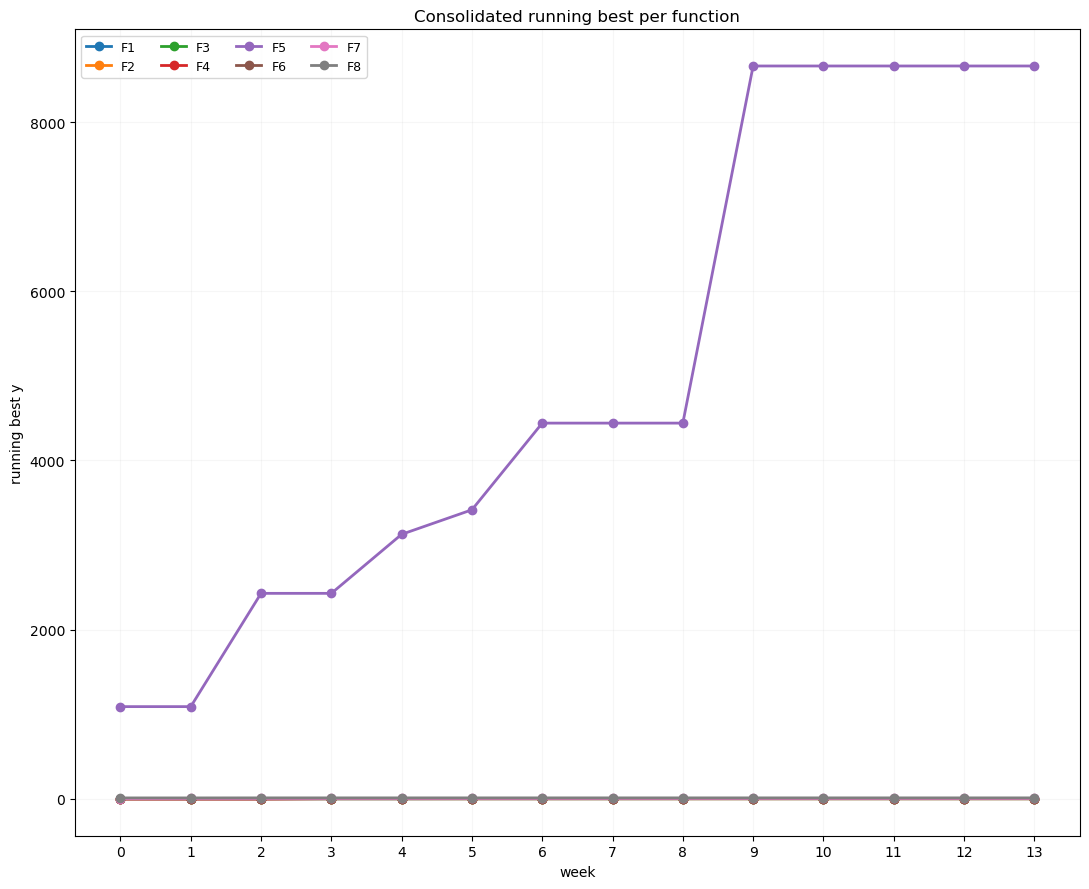

In [8]:
fig, ax = plt.subplots(figsize=(11, 9))
cmap = plt.cm.tab10.colors
for f in range(1, 9):
    s = rb[f]
    ax.plot(s.index, s.values, marker="o", lw=2, color=cmap[f-1], label=f"F{f}")
ax.set_xlabel("week"); ax.set_ylabel("running best y")
ax.set_title("Consolidated running best per function")
ax.legend(ncol=4, fontsize=9); ax.grid(alpha=0.1)
ax.set_xticks(range(0, len(weeks)+1))
plt.tight_layout(); plt.show()

## 8 · Export for Phase 2

Write the consolidated table to disk. `05_suggest_engine` loads exactly this
file, so the two notebooks share one immutable record.

In [9]:
out_path = os.path.join(OUT_DIR, "consolidated_observations.csv")
long.to_csv(out_path, index=False)
summary.to_csv(os.path.join(OUT_DIR, "function_summary.csv"), index=False)
print("Wrote:", os.path.abspath(out_path))
print("Wrote:", os.path.abspath(os.path.join(OUT_DIR, "function_summary.csv")))
print(f"\n{len(long)} observations across 8 functions, weeks 0–{len(weeks)} — ready for Phase 2.")

Wrote: C:\Users\USER\consolidated_observations.csv
Wrote: C:\Users\USER\function_summary.csv

279 observations across 8 functions, weeks 0–13 — ready for Phase 2.
